this notebook shows how LR performed better than SARIMAX.
this could be a user issue not knowing how to correctly implement SARIMAX but after talking to Dillon and past literature also supports that SARIMAX is not good

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

!pip install pmdarima
from pmdarima import auto_arima

# importing util
import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')
import utils

print('finished imports!')

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.5 MB/s eta 0:00:00
finished imports!


In [ ]:
aggregated_data = pd.read_csv('/content/drive/MyDrive/DSSI/Project/Valley Fever - Environmental/data_processed/aggregate/aggregate_all_counties_2001_2024.csv', parse_dates=['Year-Month'])
aggregated_data['log1p_rate_per_100k'] = np.log1p(aggregated_data['rate_per_100k'])
aggregated_data_trimmed = aggregated_data[(aggregated_data["Year-Month"] >= "2006-08") & (aggregated_data["Year-Month"] <= "2023-12")]

# interpolating the NaN values in Tulare
cols = ['AQI_PM10', 'Avg Soil Temp (F)']

tulare_mask = aggregated_data_trimmed['County'] == "Tulare"

aggregated_data_trimmed.loc[tulare_mask, cols] = (
    aggregated_data_trimmed.loc[tulare_mask, cols]
    .apply(lambda s: s.interpolate(method="linear"))
)

In [ ]:
monthly_all_df = pd.read_csv('/content/drive/MyDrive/DSSI/Project/code/monthly_dataset.csv', parse_dates=['Year-Month'])
monthly_all_df['log1p_rate_per_100k'] = np.log1p(monthly_all_df['rate_per_100k'])
monthly_all_trimmed = monthly_all_df[(monthly_all_df["Year-Month"] >= "2006-08-01") & (monthly_all_df["Year-Month"] <= "2023-12-01")].copy()

In [ ]:
def sarimax_pipeline(TRAIN_FRAC, X, y, dates, trace, graph):
    """
    Runs the SARIMAX model pipeline given an X (features)
    and y (target variable)
    e.g. one dataset

    Parameters
    ----------
    TRAIN_FRAC : float, percent to train on
    X : array of features to use in model
    y : target variable you are trying to predict
    dates : array of dates to use in model
    trace : boolean, True if you want to see a trace of the steps,
            False if you want to hide the steps
    graph: boolean, True if you want to print a graph of the model preds vs
           the actual values, False if you want to hide the graph

    Returns
    -------
    A dict with the following:
        "model": results,
        "auto_model": auto_model,
        "order": order,
        "seasonal_order": seasonal_order,
        "train_pred": train_pred_original,
        "test_pred": test_pred_original,
        "y_train": y_train_original,
        "y_test": y_test_original,
        "metrics": utils.compute_metrics(y_test_original, test_pred_original)
    """

    split = int(TRAIN_FRAC * len(y))
    X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

    # Scale the features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    test_dates = dates.iloc[split:]

    # auto ARIMA to find the best parameters
    auto_model = auto_arima(y_train, exogenous=X_train_scaled, seasonal=True, m=12, trace=trace, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)
    order = auto_model.order
    seasonal_order = auto_model.seasonal_order

    # model
    sarimax_model = SARIMAX(
        endog=y_train,
        exog=X_train_scaled,
        trend='n',
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    results = sarimax_model.fit()
    print(results.summary()) if (trace) else None


    # training pred (in-sample preds)
    train_pred = results.get_prediction(
        start=0,
        end=len(y_train)-1,
        exog=X_train_scaled
    )

    train_pred_log = train_pred.predicted_mean
    train_pred_original = np.expm1(train_pred_log)

    y_train_original = np.expm1(y_train)
    train_dates = dates.iloc[:split]

    # test pred (forecast)
    forecast = results.get_forecast(
        steps=len(y_test),
        exog=X_test_scaled)

    test_pred_log = forecast.predicted_mean
    test_pred_original = np.expm1(test_pred_log)
    y_test_original = np.expm1(y_test)

    if (graph):
        sns.set(style="whitegrid")
        plt.figure(figsize=(18, 9))

        # train
        # plt.plot(train_dates, y_train_original, color='black', label='Train True')
        # plt.plot(train_dates, train_pred_original, color='blue', linestyle='-.', label='Train Prediction')

        # test
        plt.plot(test_dates, y_test_original, color='black', label='Test True')
        plt.plot(test_dates, test_pred_original, color='blue', linestyle='--', label='Test Prediction')

        # show train/test split
        # plt.axvline(test_dates.iloc[0], color='red', linestyle='--', label='Train/Test Split')

        plt.suptitle("VF Rates - SARIMAX Training Fit and Forecast")
        plt.xlabel("Date")
        plt.ylabel("Rate per 100,000")
        plt.legend()

        plt.show()

    return {
        "model": results,
        "auto_model": auto_model,
        "order": order,
        "seasonal_order": seasonal_order,
        "train_pred": train_pred_original,
        "test_pred": test_pred_original,
        "y_train": y_train_original,
        "y_test": y_test_original,
        "metrics": utils.compute_metrics(y_test_original, test_pred_original)
    }

# SARIMAX test using all features on monthly aggregate data

In [ ]:
X = monthly_all_trimmed[[
    'Precipitation',
    'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    'Wind Run (miles)',
    'windeventcount',
    'Avg Soil Temp (F)',
    'AQI_PM25',
    'AQI_PM10',
    'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    'rodent_lbs_prd_used'
    ]]
y = monthly_all_trimmed['log1p_rate_per_100k']
dates = monthly_all_trimmed['Year-Month']

TRAIN_FRAC = 0.80

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=-112.738, Time=1.46 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-83.922, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-99.711, Time=0.33 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-94.964, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-85.920, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[12] intercept   : AIC=-105.935, Time=0.92 sec
 ARIMA(2,1,2)(1,0,0)[12] intercept   : AIC=-110.037, Time=1.26 sec
 ARIMA(2,1,2)(2,0,1)[12] intercept   : AIC=-110.978, Time=4.89 sec
 ARIMA(2,1,2)(1,0,2)[12] intercept   : AIC=-112.551, Time=5.60 sec
 ARIMA(2,1,2)(0,0,0)[12] intercept   : AIC=-96.684, Time=0.38 sec
 ARIMA(2,1,2)(0,0,2)[12] intercept   : AIC=-108.529, Time=2.41 sec
 ARIMA(2,1,2)(2,0,0)[12] intercept   : AIC=-109.803, Time=3.23 sec
 ARIMA(2,1,2)(2,0,2)[12] intercept   : AIC=-109.772, Time=4.68 sec
 ARIMA(1,1,2)(1,0,1)[12] intercept   : AIC=-107.535, Time=4.99 sec
 ARIMA(2,1,1)(1,0,1)[12]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_

                                      SARIMAX Results                                      
Dep. Variable:                 log1p_rate_per_100k   No. Observations:                  167
Model:             SARIMAX(4, 1, 1)x(1, 0, [], 12)   Log Likelihood                  70.066
Date:                             Tue, 14 Jul 2026   AIC                           -104.133
Time:                                     21:21:50   BIC                            -49.941
Sample:                                          0   HQIC                           -82.117
                                             - 167                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0456      0.107      0.424      0.671      -0.165       0.256
x2            -0.1787      

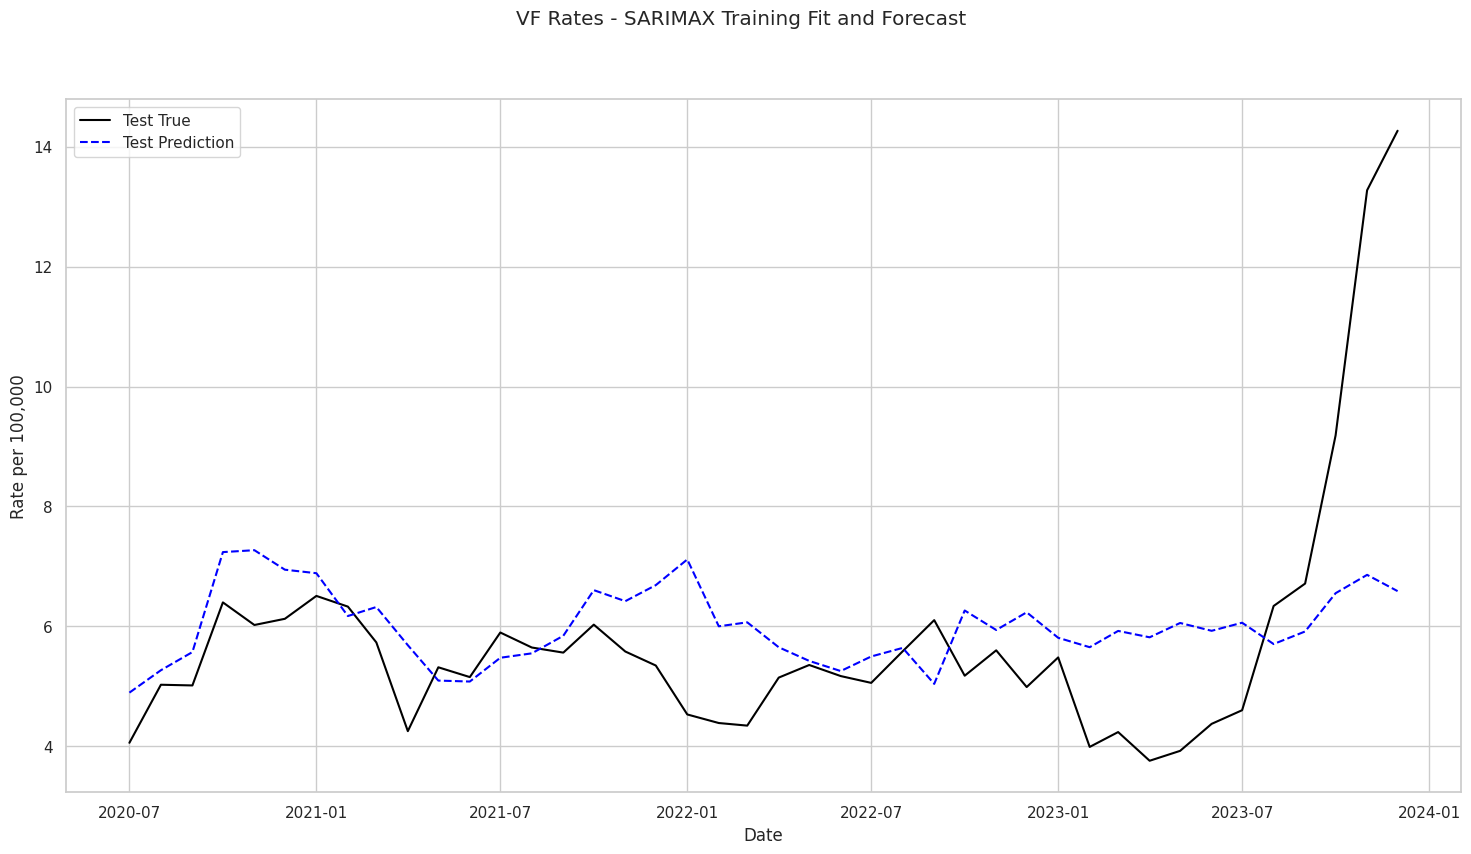

Model                           RMSE=1.91162   MAE=1.20932


In [ ]:
all_features_sarimax = sarimax_pipeline(TRAIN_FRAC=TRAIN_FRAC, X=X, y=y, dates=dates, trace=True, graph=True)

# LR test using all features on monthly aggregate data

In [ ]:
for lag in range(1, 13):
    monthly_all_trimmed[f"rate_lag{lag}"] = (
        monthly_all_trimmed["log1p_rate_per_100k"].shift(lag)
    )

X = monthly_all_trimmed[[
    'rate_lag1',
    'rate_lag2',
    'rate_lag3',
    'rate_lag4',
    'rate_lag5',
    'rate_lag6',
    'rate_lag7',
    'rate_lag8',
    'rate_lag9',
    'rate_lag10',
    'rate_lag11',
    'rate_lag12',
    'Precipitation',
    'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    'Wind Run (miles)',
    'windeventcount',
    'Avg Soil Temp (F)',
    'AQI_PM25',
    'AQI_PM10',
    'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    'rodent_lbs_prd_used'
    ]]
y = monthly_all_trimmed['log1p_rate_per_100k']
dates = monthly_all_trimmed['Year-Month']

X = X.iloc[12:]
y = y.iloc[12:]
dates = dates.iloc[12:]

TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

In [ ]:
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

all_features_lr = LinearRegression(fit_intercept=True)
all_features_lr.fit(X_train, y_train)

lr_preds_log = all_features_lr.predict(X_test)

y_test_original = np.expm1(y_test)
lr_preds_original = np.expm1(lr_preds_log)

utils.compute_metrics(y_test_original, lr_preds_original)

Model                           RMSE=0.95646   MAE=0.65952


{'RMSE': np.float64(0.9564605369381273), 'MAE': 0.6595189016172135}

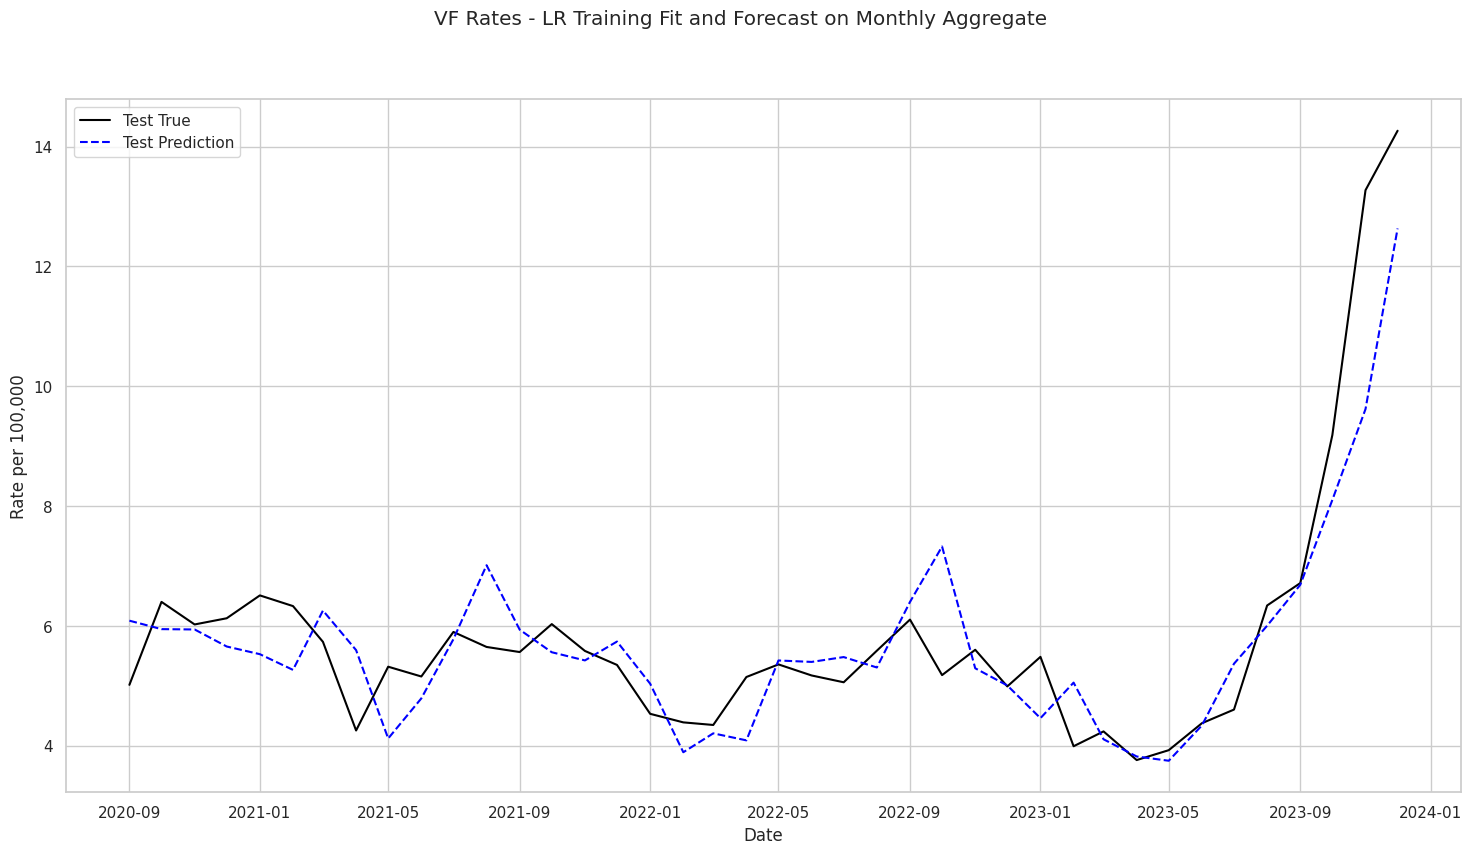

In [ ]:
train_dates = dates.iloc[:split]
test_dates = dates.iloc[split:]


sns.set(style="whitegrid")
plt.figure(figsize=(18, 9))

# train
# plt.plot(train_dates, y_train, color='black', label='Train True')
# plt.plot(train_dates, , color='blue', linestyle='-.', label='Train Prediction')

# test
plt.plot(test_dates, y_test_original, color='black', label='Test True')
plt.plot(test_dates, lr_preds_original, color='blue', linestyle='--', label='Test Prediction')

# show train/test split
# plt.axvline(test_dates.iloc[0], color='red', linestyle='--', label='Train/Test Split')

plt.suptitle("VF Rates - LR Training Fit and Forecast on Monthly Aggregate")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

#### SARIMAX test using all features on fresno data

In [ ]:
fresno_df = aggregated_data_trimmed[aggregated_data_trimmed['County'] == 'Fresno'].copy()

In [ ]:
X = fresno_df[[
    'Precipitation',
    'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    'Wind Run (miles)',
    'windeventcount',
    'Avg Soil Temp (F)',
    'AQI_PM25',
    'AQI_PM10',
    'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    'rodent_lbs_prd_used'
    ]]
y = fresno_df['log1p_rate_per_100k']
dates = fresno_df['Year-Month']

TRAIN_FRAC = 0.80

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.63 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=231.733, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=41.425, Time=0.82 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=119.359, Time=0.26 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=644.649, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=46.264, Time=0.09 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=42.758, Time=2.01 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=40.855, Time=0.28 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=42.780, Time=0.86 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=1.69 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=215.165, Time=0.13 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=40.976, Time=0.47 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=41.030, Time=1.63 sec
 ARIMA(2,0,1)(0,0,1)[12] intercept   : AIC=42.962, T

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_

                                      SARIMAX Results                                       
Dep. Variable:                  log1p_rate_per_100k   No. Observations:                  167
Model:             SARIMAX(1, 0, 0)x(0, 0, [1], 12)   Log Likelihood                 -16.520
Date:                              Tue, 14 Jul 2026   AIC                             61.040
Time:                                      21:22:25   BIC                            103.557
Sample:                                           0   HQIC                            78.310
                                              - 167                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0452      0.145     -0.311      0.755      -0.330       0.239
x2             0.01

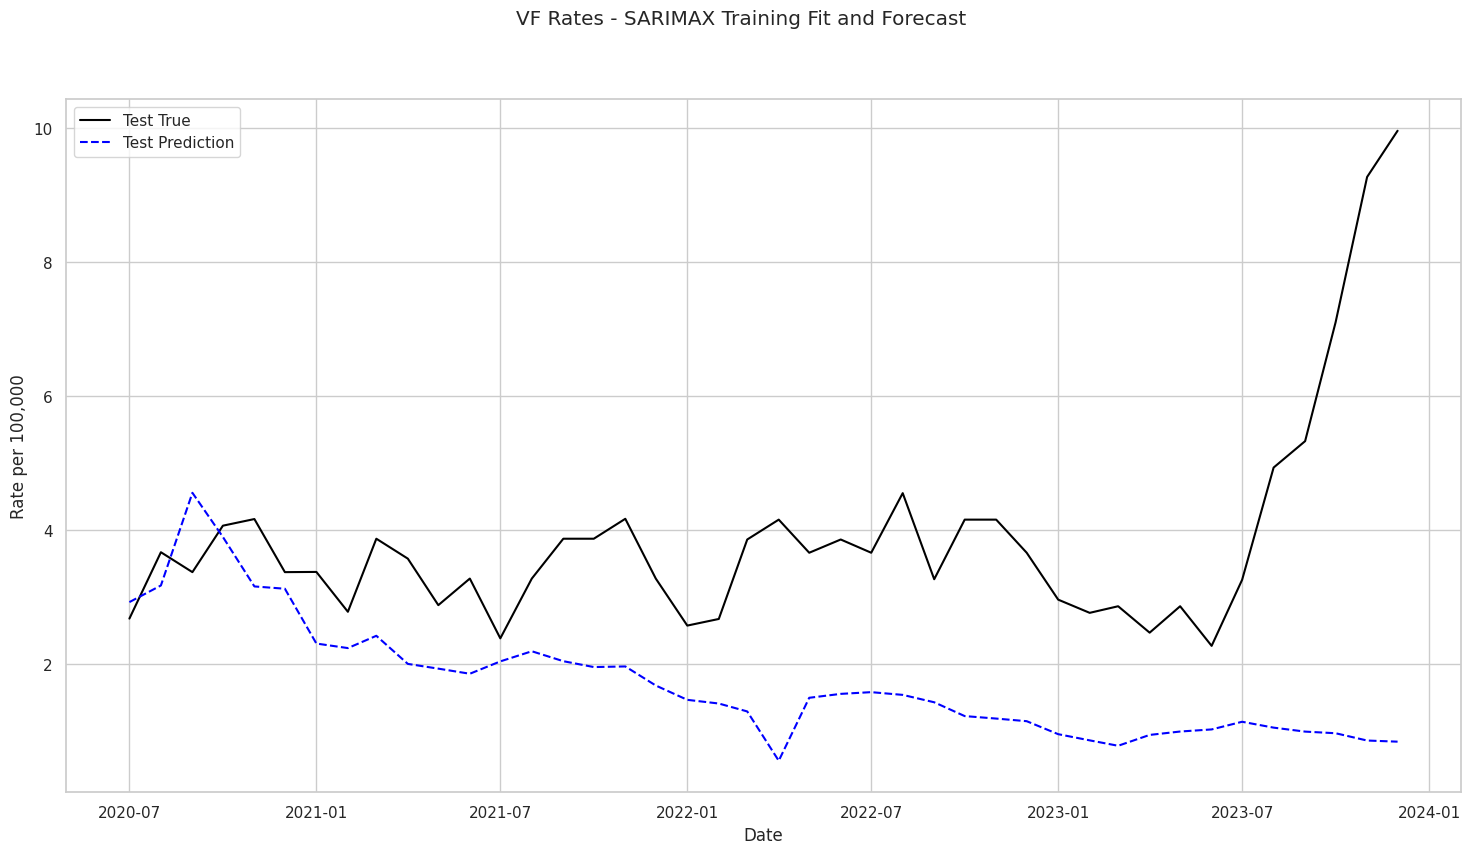

Model                           RMSE=2.88761   MAE=2.19982


In [ ]:
all_features_sarimax = sarimax_pipeline(TRAIN_FRAC=TRAIN_FRAC, X=X, y=y, dates=dates, trace=True, graph=True)

#### LR test using all features on fresno data

In [ ]:
for lag in range(1, 13):
    fresno_df[f"rate_lag{lag}"] = (
        fresno_df["log1p_rate_per_100k"].shift(lag)
    )

X = fresno_df[[
    'rate_lag1',
    'rate_lag2',
    'rate_lag3',
    'rate_lag4',
    'rate_lag5',
    'rate_lag6',
    'rate_lag7',
    'rate_lag8',
    'rate_lag9',
    'rate_lag10',
    'rate_lag11',
    'rate_lag12',
    'Precipitation',
    'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    'Wind Run (miles)',
    'windeventcount',
    'Avg Soil Temp (F)',
    'AQI_PM25',
    'AQI_PM10',
    'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    'rodent_lbs_prd_used'
    ]]
y = fresno_df['log1p_rate_per_100k']
dates = fresno_df['Year-Month']

X = X.iloc[12:]
y = y.iloc[12:]
dates = dates.iloc[12:]

TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

In [ ]:
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

all_features_lr = LinearRegression(fit_intercept=True)
all_features_lr.fit(X_train, y_train)

lr_preds_log = all_features_lr.predict(X_test)

y_test_original = np.expm1(y_test)
lr_preds_original = np.expm1(lr_preds_log)

utils.compute_metrics(y_test_original, lr_preds_original)

Model                           RMSE=0.85984   MAE=0.63990


{'RMSE': np.float64(0.8598388858171679), 'MAE': 0.6398965079452316}

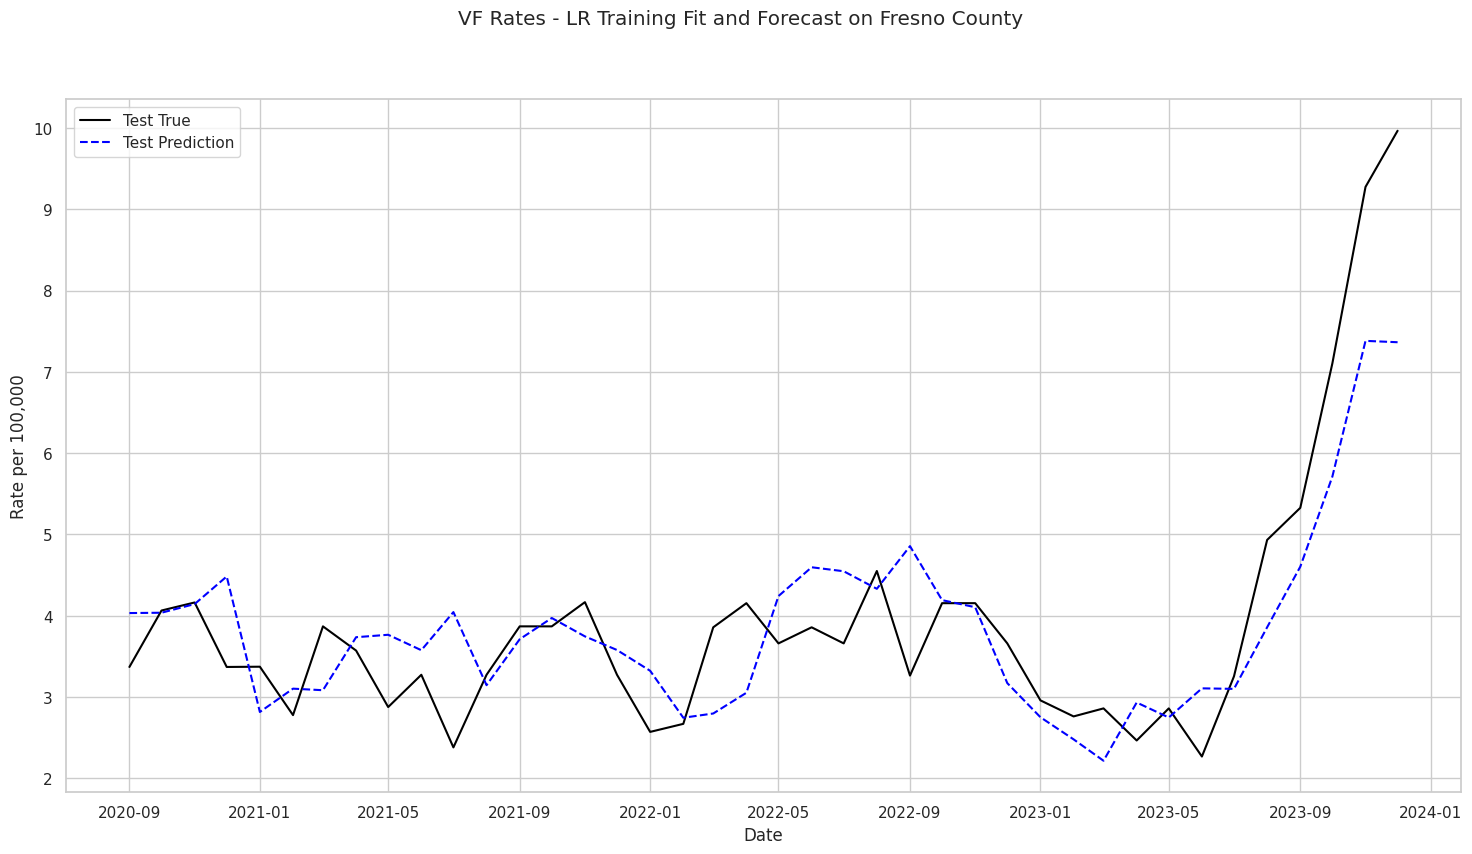

In [ ]:
train_dates = dates.iloc[:split]
test_dates = dates.iloc[split:]


sns.set(style="whitegrid")
plt.figure(figsize=(18, 9))

# train
# plt.plot(train_dates, y_train, color='black', label='Train True')
# plt.plot(train_dates, , color='blue', linestyle='-.', label='Train Prediction')

# test
plt.plot(test_dates, y_test_original, color='black', label='Test True')
plt.plot(test_dates, lr_preds_original, color='blue', linestyle='--', label='Test Prediction')

# show train/test split
# plt.axvline(test_dates.iloc[0], color='red', linestyle='--', label='Train/Test Split')

plt.suptitle("VF Rates - LR Training Fit and Forecast on Fresno County")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

#### SARIMAX test using all features on kern data

In [ ]:
kern_df = aggregated_data_trimmed[aggregated_data_trimmed['County'] == 'Kern'].copy()

In [ ]:
X = kern_df[[
    'Precipitation',
    'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    'Wind Run (miles)',
    'windeventcount',
    'Avg Soil Temp (F)',
    'AQI_PM25',
    'AQI_PM10',
    'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    'rodent_lbs_prd_used'
    ]]
y = kern_df['log1p_rate_per_100k']
dates = kern_df['Year-Month']

TRAIN_FRAC = 0.80

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.43 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=35.524, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=34.558, Time=0.25 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=35.586, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=33.528, Time=0.08 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=33.176, Time=0.15 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=33.085, Time=0.51 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=1.67 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.68 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=33.824, Time=1.11 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=34.033, Time=2.13 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : AIC=35.338, Time=4.83 sec
 ARIMA(0,1,0)(2,0,0)[12]             : AIC=31.085, Time=0.24 sec
 ARIMA(0,1,0)(1,0,0)[12]             : AIC=31.181, Time=0.08 sec
 ARIMA(0,1,0)(2,0,1)[12]             : AIC=inf, Time=1.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                log1p_rate_per_100k   No. Observations:                  167
Model:             SARIMAX(0, 1, 0)x(2, 0, 0, 12)   Log Likelihood                   4.769
Date:                            Tue, 14 Jul 2026   AIC                             18.462
Time:                                    21:48:24   BIC                             59.843
Sample:                                         0   HQIC                            35.277
                                            - 167                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0798      0.142     -0.562      0.574      -0.358       0.199
x2             0.3014      0.210   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


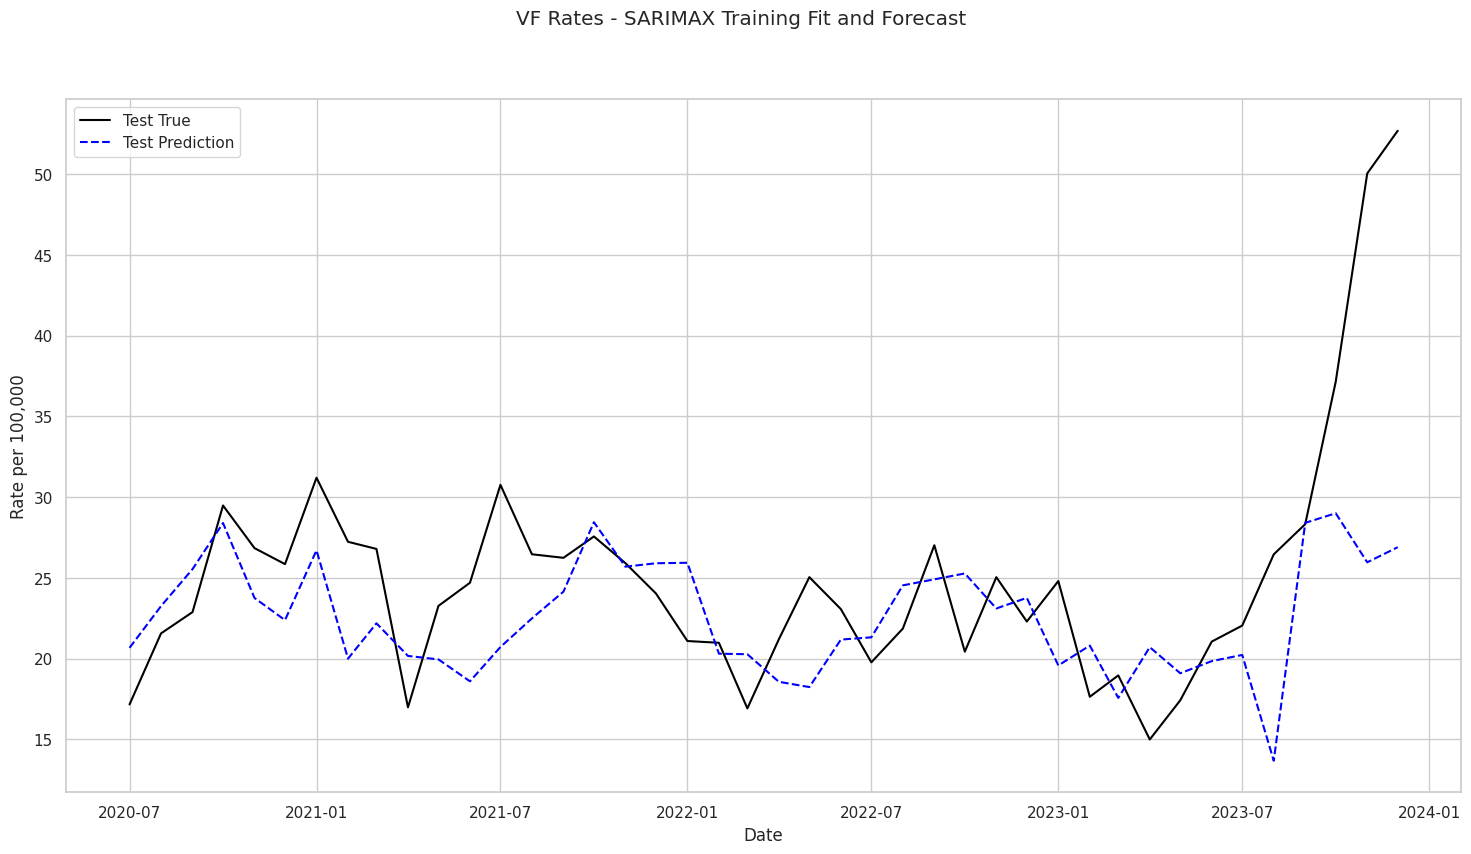

Model                           RMSE=6.92063   MAE=4.50867


In [ ]:
all_features_sarimax = sarimax_pipeline(TRAIN_FRAC=TRAIN_FRAC, X=X, y=y, dates=dates, trace=True, graph=True)

#### LR test using all features on kern data

In [ ]:
for lag in range(1, 13):
    kern_df[f"rate_lag{lag}"] = (
        kern_df["log1p_rate_per_100k"].shift(lag)
    )

X = kern_df[[
    'rate_lag1',
    'rate_lag2',
    'rate_lag3',
    'rate_lag4',
    'rate_lag5',
    'rate_lag6',
    'rate_lag7',
    'rate_lag8',
    'rate_lag9',
    'rate_lag10',
    'rate_lag11',
    'rate_lag12',
    'Precipitation',
    'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    'Wind Run (miles)',
    'windeventcount',
    'Avg Soil Temp (F)',
    'AQI_PM25',
    'AQI_PM10',
    'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    'rodent_lbs_prd_used'
    ]]
y = kern_df['log1p_rate_per_100k']
dates = kern_df['Year-Month']

X = X.iloc[12:]
y = y.iloc[12:]
dates = dates.iloc[12:]

TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

In [ ]:
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

all_features_lr = LinearRegression(fit_intercept=True)
all_features_lr.fit(X_train, y_train)

lr_preds_log = all_features_lr.predict(X_test)

y_test_original = np.expm1(y_test)
lr_preds_original = np.expm1(lr_preds_log)

utils.compute_metrics(y_test_original, lr_preds_original)

Model                           RMSE=8.95109   MAE=5.48355


{'RMSE': np.float64(8.951093306192274), 'MAE': 5.48354903848187}

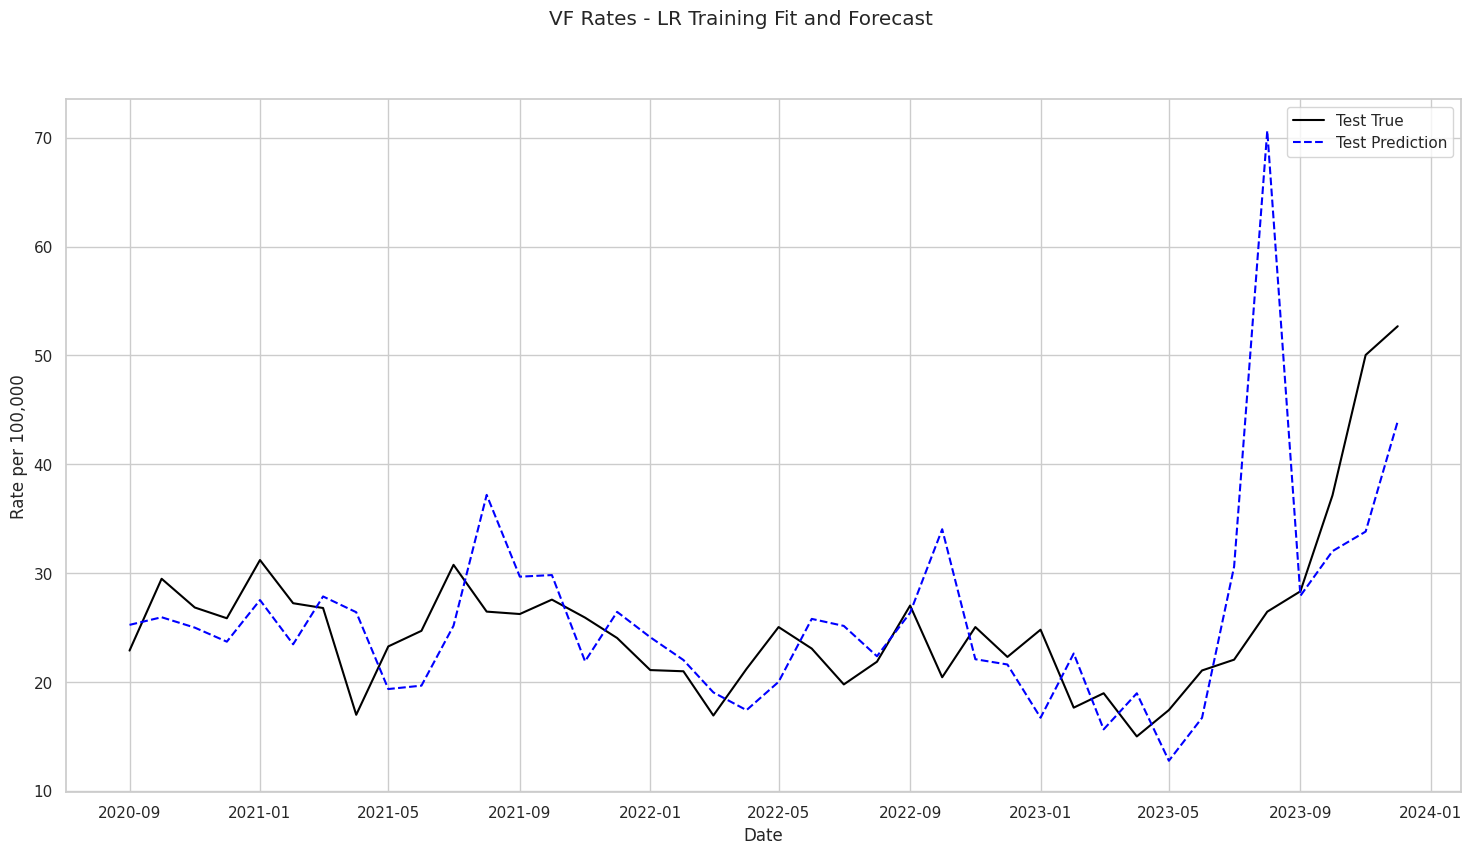

In [ ]:
train_dates = dates.iloc[:split]
test_dates = dates.iloc[split:]


sns.set(style="whitegrid")
plt.figure(figsize=(18, 9))

# train
# plt.plot(train_dates, y_train, color='black', label='Train True')
# plt.plot(train_dates, , color='blue', linestyle='-.', label='Train Prediction')

# test
plt.plot(test_dates, y_test_original, color='black', label='Test True')
plt.plot(test_dates, lr_preds_original, color='blue', linestyle='--', label='Test Prediction')

# show train/test split
# plt.axvline(test_dates.iloc[0], color='red', linestyle='--', label='Train/Test Split')

plt.suptitle("VF Rates - LR Training Fit and Forecast")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

#### SARIMAX test using AQI_PM10, fungicide, windspeed on fresno data

In [ ]:
fresno_df = aggregated_data_trimmed[aggregated_data_trimmed['County'] == 'Fresno']

In [ ]:
X = fresno_df[[
    # 'Precipitation',
    # 'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    # 'Wind Run (miles)',
    # 'windeventcount',
    # 'Avg Soil Temp (F)',
    # 'AQI_PM25',
    'AQI_PM10',
    # 'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    # 'rodent_lbs_prd_used'
    ]]
y = fresno_df['log1p_rate_per_100k']
dates = fresno_df['Year-Month']

TRAIN_FRAC = 0.80

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=3.31 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=231.733, Time=0.10 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=41.425, Time=3.00 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=119.359, Time=0.23 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=644.649, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=46.264, Time=0.08 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=42.758, Time=1.74 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.80 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=40.855, Time=0.24 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=42.780, Time=0.68 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=inf, Time=1.48 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=215.165, Time=0.12 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=40.976, Time=0.29 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=41.030, Time=0.35 sec
 ARIMA(2,0,1)(0,0,1)[12] intercept   : AIC=42.962, T

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                                      SARIMAX Results                                       
Dep. Variable:                  log1p_rate_per_100k   No. Observations:                  167
Model:             SARIMAX(1, 0, 0)x(0, 0, [1], 12)   Log Likelihood                 -20.328
Date:                              Wed, 15 Jul 2026   AIC                             52.655
Time:                                      01:39:26   BIC                             70.877
Sample:                                           0   HQIC                            60.057
                                              - 167                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0351      0.139     -0.252      0.801      -0.308       0.237
x2             0.03

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


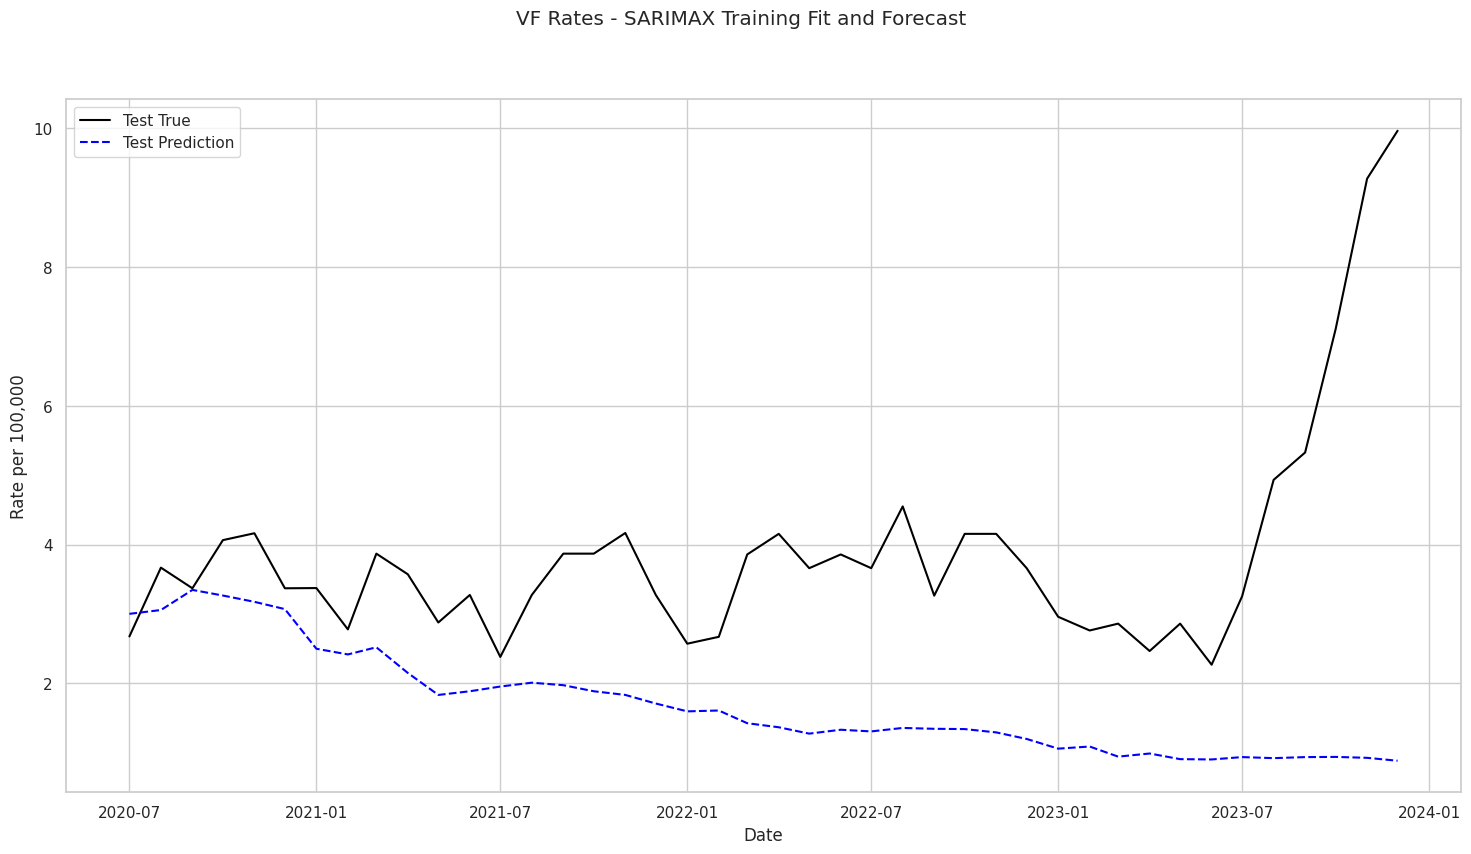

Model                           RMSE=2.86747   MAE=2.17428


In [ ]:
all_features_sarimax = sarimax_pipeline(TRAIN_FRAC=TRAIN_FRAC, X=X, y=y, dates=dates, trace=True, graph=True)

#### LR test using AQI_PM10, fungicide, windspeed on fresno data

In [ ]:
for lag in range(1, 13):
    fresno_df[f"rate_lag{lag}"] = (
        fresno_df["log1p_rate_per_100k"].shift(lag)
    )

X = fresno_df[[
    'rate_lag1',
    'rate_lag2',
    'rate_lag3',
    'rate_lag4',
    'rate_lag5',
    'rate_lag6',
    'rate_lag7',
    'rate_lag8',
    'rate_lag9',
    'rate_lag10',
    'rate_lag11',
    'rate_lag12',
    # 'Precipitation',
    # 'Avg Rel Hum (%)',
    'Avg Wind Speed (mph)',
    # 'Wind Run (miles)',
    # 'windeventcount',
    # 'Avg Soil Temp (F)',
    # 'AQI_PM25',
    'AQI_PM10',
    # 'FIRE_Acres_Burned',
    'fungicide_lbs_prd_used',
    # 'rodent_lbs_prd_used'
    ]]
y = fresno_df['log1p_rate_per_100k']
dates = fresno_df['Year-Month']

X = X.iloc[12:]
y = y.iloc[12:]
dates = dates.iloc[12:]

TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

In [ ]:
X_train, X_test, y_train, y_test = utils.test_train(TRAIN_FRAC, X, y)

all_features_lr = LinearRegression(fit_intercept=True)
all_features_lr.fit(X_train, y_train)

lr_preds_log = all_features_lr.predict(X_test)

y_test_original = np.expm1(y_test)
lr_preds_original = np.expm1(lr_preds_log)

utils.compute_metrics(y_test_original, lr_preds_original)

Model                           RMSE=0.90917   MAE=0.68525


{'RMSE': np.float64(0.9091674799389595), 'MAE': 0.6852456477738544}

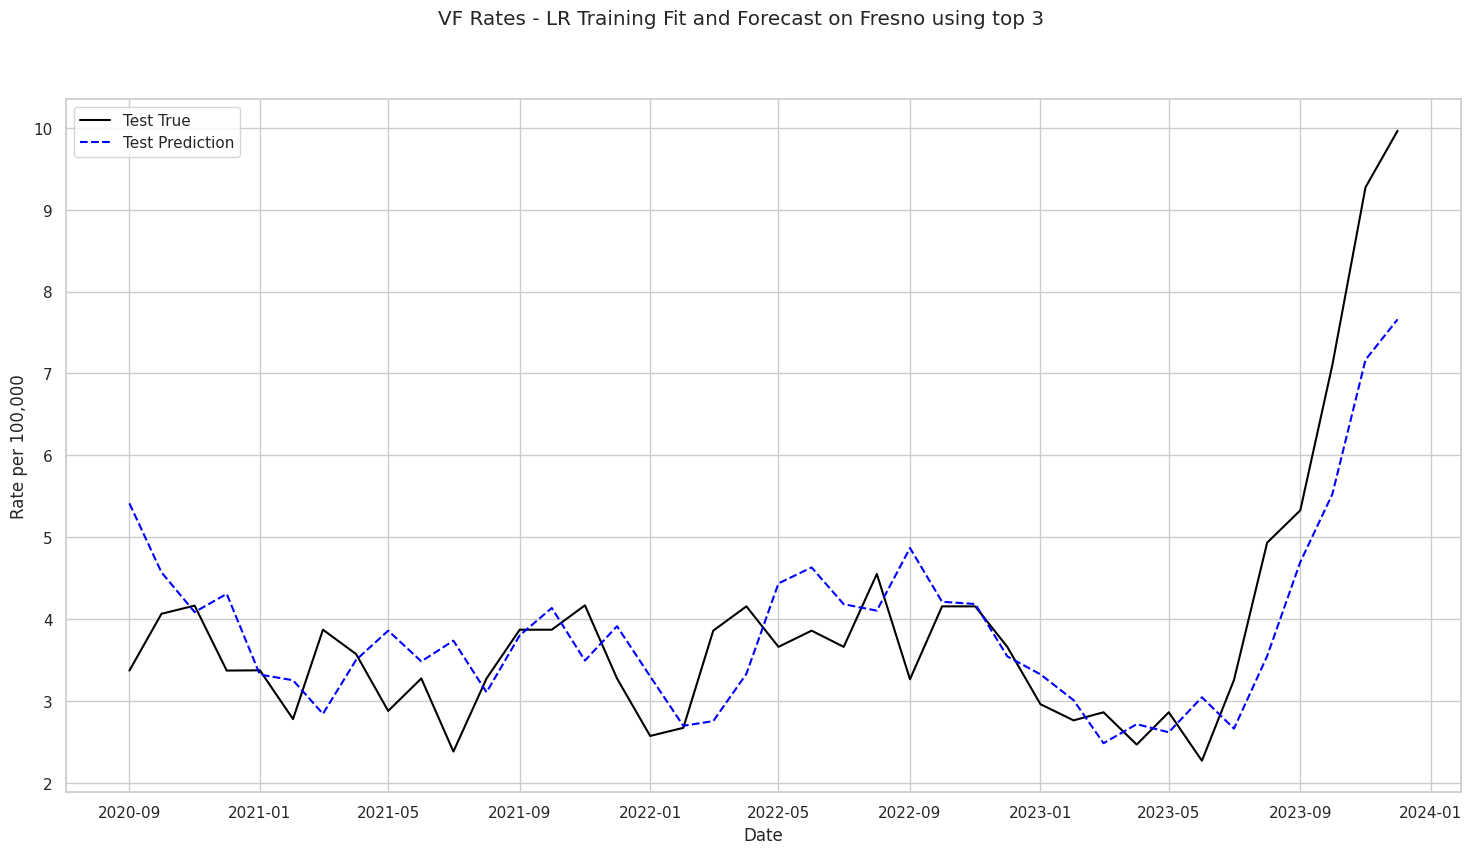

In [ ]:
train_dates = dates.iloc[:split]
test_dates = dates.iloc[split:]


sns.set(style="whitegrid")
plt.figure(figsize=(18, 9))

# train
# plt.plot(train_dates, y_train, color='black', label='Train True')
# plt.plot(train_dates, , color='blue', linestyle='-.', label='Train Prediction')

# test
plt.plot(test_dates, y_test_original, color='black', label='Test True')
plt.plot(test_dates, lr_preds_original, color='blue', linestyle='--', label='Test Prediction')

# show train/test split
# plt.axvline(test_dates.iloc[0], color='red', linestyle='--', label='Train/Test Split')

plt.suptitle("VF Rates - LR Training Fit and Forecast on Fresno using top 3")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()